In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
from transformers import GPT2Model,GPT2Tokenizer

# pretrained GPT-2 model and tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

/opt/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/anaconda3/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [3]:
# get the Word Token Embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

In [4]:
# words of interest
word1 = 'banana'
word2 = 'apple'
word3 = 'cosmic'

# decomposition
for w in [word1,word2,word3]:
  t = tokenizer.encode(w)
  print(f'"{w}" comprises {len(t)} tokens:\n   {[tokenizer.decode(i) for i in t]}\n')

"banana" comprises 2 tokens:
   ['ban', 'ana']

"apple" comprises 1 tokens:
   ['apple']

"cosmic" comprises 2 tokens:
   ['cos', 'mic']



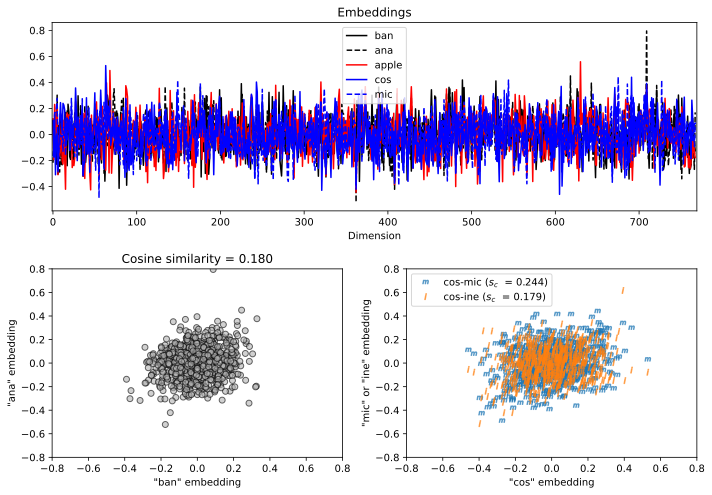

In [ ]:
# setup the figure subplot geometry
fig = plt.figure(figsize=(10,7))
gs = GridSpec(2,2)
ax0 = fig.add_subplot(gs[0,:])
ax1 = fig.add_subplot(gs[1,0])
ax2 = fig.add_subplot(gs[1,1])


# plot the embeddings by dimension
colors = 'krb'
linestyles = ['-','--','-.',':']
for idx,word in enumerate([word1,word2,word3]):
  wordidx = tokenizer.encode(word)
  for j in range(len(wordidx)):
    ax0.plot(embeddings[wordidx[j],:],linestyle=linestyles[j],color=colors[idx],label=tokenizer.decode(wordidx[j]))

ax0.set(xlabel='Dimension',title='Embeddings',xlim=[-1,embeddings.shape[1]+1])
ax0.legend()



# cosine similarity between 'ban' and 'ana'
v1 = embeddings[tokenizer.encode('ban')]
v2 = embeddings[tokenizer.encode('ana')]
cossim = np.sum(v1*v2)/(np.linalg.norm(v1)*np.linalg.norm(v2))

# plot the embeddings by each other
ax1.plot(v1,v2,'ko',markerfacecolor=[.7,.7,.7,.6])
ax1.set(xlim=[-.8,.8],ylim=[-.8,.8],xlabel='"ban" embedding',ylabel='"ana" embedding',
        title=f'Cosine similarity = {cossim:.3f}')



# plot the "cos" for two endings
for s in ['mic','ine']:

  # cosine similarity
  v1 = embeddings[tokenizer.encode('cos')].squeeze()
  v2 = embeddings[tokenizer.encode(s)].squeeze()
  cossim = np.sum(v1*v2) / (np.linalg.norm(v1)*np.linalg.norm(v2))

  # plot
  ax2.plot(v1,v2,marker=f'${s[0]}$',linestyle='none',alpha=.6,label=f'cos-{s} ($s_c$  = {cossim:.3f})')

ax2.legend(fontsize=10)
ax2.set(xlim=[-.8,.8],ylim=[-.8,.8],xlabel='"cos" embedding',ylabel='"mic" or "ine" embedding')


# final touches
plt.tight_layout()
plt.show()